In [1]:
import pandas as pd
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_theme(style='whitegrid', palette='Blues_r')
print("Setup Complete")

Setup Complete


In [2]:
df = pd.read_csv(r"C:\users\andre\Amazon Sale Report.csv")
print(df.head(10))

   index             Order ID      Date                        Status  \
0      0  405-8078784-5731545  04-30-22                     Cancelled   
1      1  171-9198151-1101146  04-30-22  Shipped - Delivered to Buyer   
2      2  404-0687676-7273146  04-30-22                       Shipped   
3      3  403-9615377-8133951  04-30-22                     Cancelled   
4      4  407-1069790-7240320  04-30-22                       Shipped   
5      5  404-1490984-4578765  04-30-22                       Shipped   
6      6  408-5748499-6859555  04-30-22                       Shipped   
7      7  406-7807733-3785945  04-30-22  Shipped - Delivered to Buyer   
8      8  407-5443024-5233168  04-30-22                     Cancelled   
9      9  402-4393761-0311520  04-30-22                       Shipped   

  Fulfilment Sales Channel  ship-service-level    Style                  SKU  \
0   Merchant      Amazon.in           Standard   SET389       SET389-KR-NP-S   
1   Merchant      Amazon.in         

C:\Users\andre\AppData\Local\Temp\ipykernel_32148\874877176.py:1: DtypeWarning: Columns (0: Unnamed: 22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\users\andre\Amazon Sale Report.csv")


## Data Cleaning and Preparation

The dataset is preprocessed to ensure consistency and usability for analysis. This includes:

- Converting date columns to datetime format
- Handling missing or inconsistent values
- Standardizing categorical variables
- Creating derived columns such as cancellation indicators and time-based features

These steps improve data quality and enable reliable grouping, filtering, and visualization.

In [3]:
print(df.isna().sum())
print()
print(df.duplicated().sum())
print()
print(df.dtypes)
print()
print(df.info())


index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
Unnamed: 22           49050
dtype: int64

0

index                   int64
Order ID                  str
Date                      str
Status                    str
Fulfilment                str
Sales Channel             str
ship-service-level        str
Style                     str
SKU                       str
Category                  str
Size       

In [4]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
print(df.dtypes)

index                          int64
Order ID                         str
Date                  datetime64[us]
Status                           str
Fulfilment                       str
Sales Channel                    str
ship-service-level               str
Style                            str
SKU                              str
Category                         str
Size                             str
ASIN                             str
Courier Status                   str
Qty                            int64
currency                         str
Amount                       float64
ship-city                        str
ship-state                       str
ship-postal-code             float64
ship-country                     str
promotion-ids                    str
B2B                             bool
fulfilled-by                     str
Unnamed: 22                   object
dtype: object


C:\Users\andre\AppData\Local\Temp\ipykernel_32148\1598909565.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


In [5]:
df = df.drop(columns=['fulfilled-by', 'Unnamed: 22', 'promotion-ids'])
df = df.dropna(subset=['Courier Status'])
df['Category'] = df['Category'].str.lower().str.title()
print(df.isna().sum())
print(df.shape)
print()
print(df.head(10))

index                    0
Order ID                 0
Date                     0
Status                   0
Fulfilment               0
Sales Channel            0
ship-service-level       0
Style                    0
SKU                      0
Category                 0
Size                     0
ASIN                     0
Courier Status           0
Qty                      0
currency              6059
Amount                6059
ship-city               30
ship-state              30
ship-postal-code        30
ship-country            30
B2B                      0
dtype: int64
(122103, 21)

    index             Order ID       Date                        Status  \
1       1  171-9198151-1101146 2022-04-30  Shipped - Delivered to Buyer   
2       2  404-0687676-7273146 2022-04-30                       Shipped   
4       4  407-1069790-7240320 2022-04-30                       Shipped   
5       5  404-1490984-4578765 2022-04-30                       Shipped   
6       6  408-5748499-6859555 

In [6]:
print(df['currency'].unique())
print(df['Amount'].unique())

<StringArray>
['INR', nan]
Length: 2, dtype: str
[ 406.  329.  574.  824.  653.  399.   nan  363.  685.  364.  657.  771.
  544.  458.  886.  517.  666.  376.  499.  582.  299.  459.  791. 1233.
  487.  368.  699.  885.  424. 1126.  788.  759. 1146.  665.  429.  848.
  654. 1033.  390.  493.  721.  597.  888.  353.  599.  518.  295.  852.
  909.  432.  545.  696.  631.  316.  362.  751.  684. 1281. 1186.  377.
  744.  859.  825.  680.  725. 1338.  472.  832.  692.  318.  807.  311.
  387.  348.  549.  635.  790.  375. 1115.  579.  442.  690. 1399.  999.
  496.  845.  568.  484.  626.  563.  512. 1112.  583.  534.  319.  795.
  588.  497.  449.    0.  463.  591.  435. 1099.  533.  968.  486. 1065.
 2130.  682. 1140.  660.  345.  339. 1133. 1463.  471.  342.  736. 1260.
  475.  782. 1173.  379. 1999.  737.  899.  426.  995.  562.  476.  625.
  505. 1149. 1499.  835.  789.  620.  511.  352.  874.  259. 1221.  595.
  612.  820.  801.  540. 1213.  939.  279.  469.  989. 1249.  393.  922.
  

In [7]:
print(df['Status'].value_counts())

Status
Shipped                          77804
Shipped - Delivered to Buyer     28761
Cancelled                        11471
Shipped - Returned to Seller      1950
Shipped - Picked Up                973
Pending                            658
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipping                             8
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64


## Which product category has the highest percentage of cancelled orders?

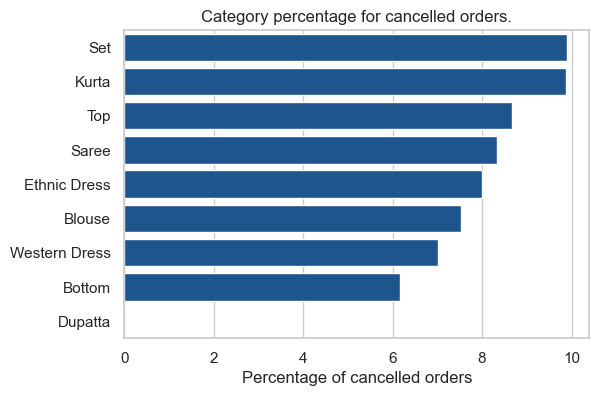

In [8]:
df['Label'] = (df['Status'] == 'Cancelled').map({True : 1, False : 0})
df_category = df.groupby('Category').agg(
    Total_Orders = ('Status', 'count'),
    Cancelled_Orders = ('Label', 'sum')
)
df_category['Percentage'] = ((df_category['Cancelled_Orders'] / df_category['Total_Orders']) * 100).round(2)
top_cancelled = df_category.sort_values(by='Percentage', ascending=False).reset_index()
top_cancelled # to see the data set that came out before making the chart
fig, ax = plt.subplots(figsize = (6, 4))
sns.barplot(data=top_cancelled, x = 'Percentage', y = 'Category', ax = ax)
plt.title('Category percentage for cancelled orders.')
plt.ylabel("")
plt.xlabel('Percentage of cancelled orders')
plt.show()


### Finding
Set and Kurta show the highest cancellation rates at approximately 9.9%, while Dupatta 
records zero cancellations — though with only 3 total orders this is not statistically 
meaningful. Cancellation rates are clustered between 6% and 10% across all major 
categories, suggesting that product type alone does not drive cancellations. 
Other factors such as sizing, delivery time or pricing may play a larger role.

---

## Which Indian states generate the most revenue, and what is the average order value per state?

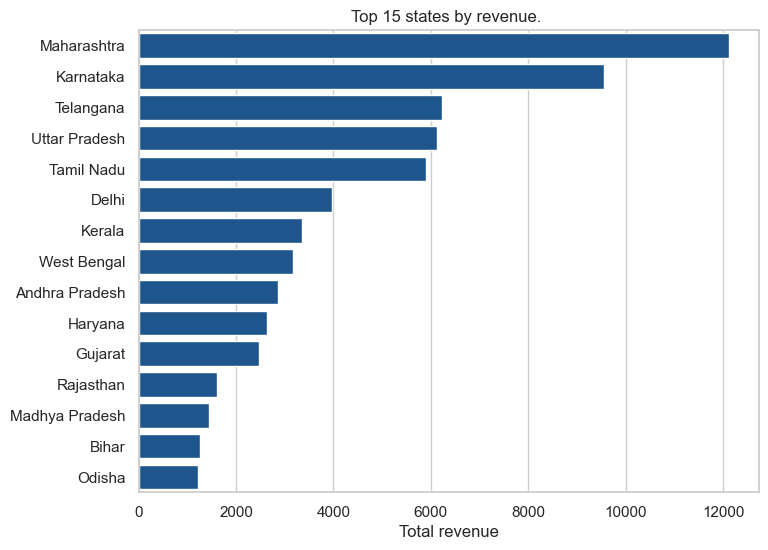

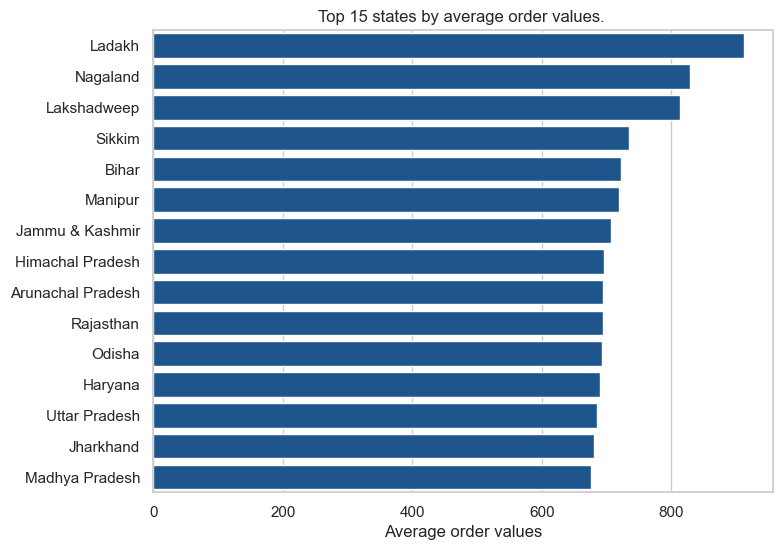

In [9]:
df_shipped = df[df['Status'].str.contains('Shipped')]
df_shipped = df_shipped.dropna(subset='Amount')
df_shipped['ship-state'] = df_shipped['ship-state'].str.lower().str.title()
shipped_state = df_shipped.groupby('ship-state').agg(
    Total_Rev = ('Amount', 'sum'),
    Avg_Order_Value = ('Amount', 'mean')
)

top_rev = shipped_state.sort_values(by='Total_Rev', ascending=False).reset_index().round(2)
top_rev_state = top_rev.head(15)
top_rev_state['Total_Rev'] = top_rev_state['Total_Rev'] / 1000
fig, ax = plt.subplots(figsize = (8, 6))
sns.barplot(data=top_rev_state, x = 'Total_Rev', y = 'ship-state', ax = ax)
plt.title("Top 15 states by revenue. ")
plt.ylabel("")
plt.xlabel("Total revenue")
plt.show()

top_avg_order = shipped_state.sort_values(by='Avg_Order_Value', ascending=False).reset_index().round(2)
top_avg_order_state = top_avg_order.head(15)
fig, ax = plt.subplots(figsize = (8, 6))
sns.barplot(data=top_avg_order_state, x = 'Avg_Order_Value', y = 'ship-state', ax = ax)
plt.title("Top 15 states by average order values. ")
plt.ylabel("")
plt.xlabel("Average order values")
plt.show()





### Finding
Maharashtra dominates total revenue at nearly double second-place Karnataka, 
reflecting its position as India's largest consumer market. The top 5 states — 
Maharashtra, Karnataka, Telangana, Uttar Pradesh and Tamil Nadu — account for 
the majority of all revenue generated.

The average order value chart tells a different story. Smaller states occasionally 
show higher average order values, suggesting that while volume concentrates in 
major metros, customers elsewhere may be purchasing higher-value items.

---


## Does Amazon fulfilment or Merchant fulfilment have a lower cancellation rate?

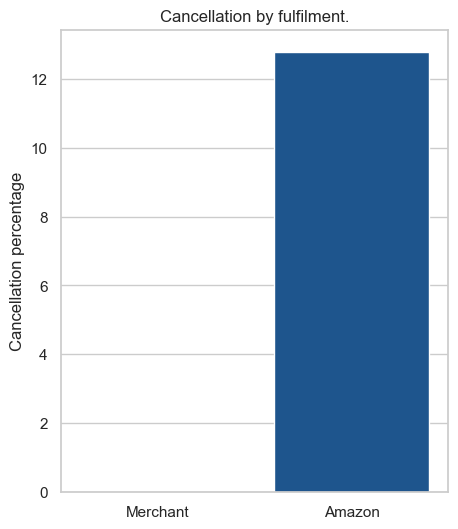

In [10]:
df_fulfilment = df.groupby('Fulfilment').agg(
    Total = ('Fulfilment', 'count'),
    Cancelled = ('Label', 'sum')
)
df_fulfilment['Percentage'] = ((df_fulfilment['Cancelled'] / df_fulfilment['Total']) * 100).round(2)
df_fulfilment
lowest_cancellation_rate = df_fulfilment.sort_values(by='Percentage', ascending=True).reset_index()
lowest_cancellation_rate
fig, ax = plt.subplots(figsize = (5, 6))
sns.barplot(data=lowest_cancellation_rate, x = 'Fulfilment', y = 'Percentage', ax=ax)
plt.title("Cancellation by fulfilment.")
plt.xlabel("")
plt.ylabel("Cancellation percentage")
plt.show()



### Finding
Amazon fulfilment records a 12.79% cancellation rate while Merchant fulfilment 
shows 0%. This is not evidence that Merchant performs better — an investigation 
of Merchant order statuses confirms that the Cancelled label does not appear 
at all for Merchant orders, suggesting cancellations are recorded differently 
or handled outside the platform. Direct comparison between fulfilment methods 
is not reliable with this dataset.

---

## How did total revenue change month by month, and which month had the biggest growth?

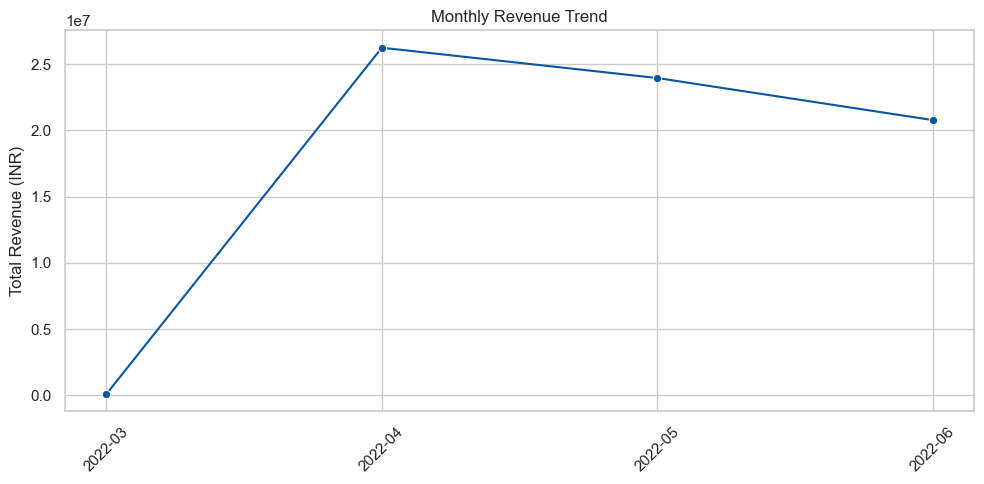

In [11]:
monthly_rev = df_shipped.copy()
monthly_rev['Month'] = monthly_rev['Date'].dt.to_period('M')
total_monthly_rev = monthly_rev.groupby('Month').agg(
    Total_rev = ('Amount', 'sum')
).reset_index()
total_monthly_rev['Month'] = total_monthly_rev['Month'].astype(str)
total_monthly_rev['pct_change'] = total_monthly_rev['Total_rev'].pct_change() * 100

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=total_monthly_rev, x='Month', y='Total_rev', ax=ax, marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('')
plt.ylabel('Total Revenue (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Finding
Revenue trends show clear variation across the months covered in the dataset. 
The percentage change highlights which months experienced the sharpest growth 
or decline relative to the previous month. As this dataset covers a partial 
year, the first month will always show no change since there is no prior 
period to compare against.

---

## Which sizes are most popular for each product category?

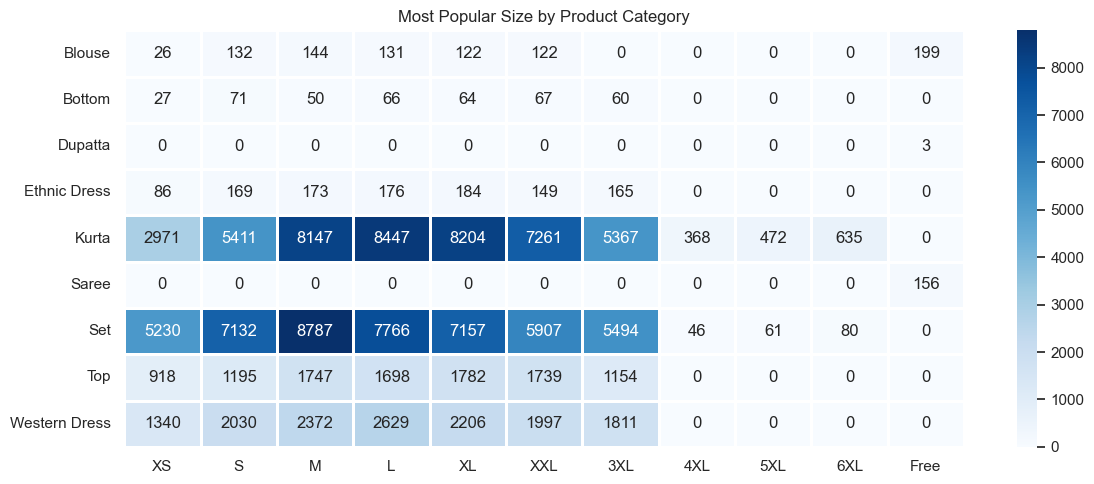

In [12]:
df_sizes = df.groupby(['Category', 'Size']).agg(
    Total = ('Size', 'count')
)
popular = pd.pivot_table(
    data=df_sizes,
    index='Category',
    columns='Size',
    values='Total'
).fillna(0)
size_order = ['XS', 'S', 'M', 'L', 'XL', 'XXL', '3XL', '4XL', '5XL', '6XL', 'Free']
popular = popular.reindex(columns=[s for s in size_order if s in popular.columns])
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(popular, annot=True, fmt='g', cmap='Blues', linewidths=1, ax=ax)
plt.title('Most Popular Size by Product Category')
plt.ylabel('')
plt.xlabel('')
plt.tight_layout()
plt.show()

### Finding
Set and Kurta dominate in volume across all sizes, consistent with their 
position as the highest-selling categories overall. Medium, Large and XL 
are consistently the most popular sizes, while XS and sizes above XXL show 
significantly lower demand across all categories. This is directly actionable 
for inventory planning — overstocking low-demand sizes increases storage 
costs and return risk.